**Worksheet 3**

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Task 1: Implementation of MCP Neurons**

MCP Neuron AND

In [27]:
def MCP_Neurons_AND(X1, X2, T):
    # both inputs must have same length
    assert len(X1) == len(X2)

    # store outputs
    state_neuron = []

    for x1, x2 in zip(X1, X2):
        # add two inputs
        s = x1 + x2
        # apply threshold
        state_neuron.append(1 if s >= T else 0)

    return state_neuron

In [28]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # threshold for AND

result_and = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result_and)

AND Output: [0, 0, 0, 1]


MCP Neuron OR

In [29]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for x1, x2 in zip(X1, X2):
        s = x1 + x2
        state_neuron.append(1 if s >= T else 0)  # apply threshold

    return state_neuron

In [30]:
T = 1  # threshold for OR

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)

OR Output: [0, 1, 1, 1]


Question 1: Limitations of MCP Neurons

The McCulloch-Pitts (MCP) neuron is a very simple computational model that has several important limitations.
No learning capability: The MCP neuron cannot learn from data; weights and threshold must be manually set.

Limited to linear problems: It can only solve linearly separable problems such as AND and OR.

Fails for non-linear tasks: It cannot solve problems like XOR which require non-linear decision boundaries.

Binary output only: It produces only 0 or 1 output, so it cannot handle continuous or probabilistic values.

No adaptability: The model cannot adjust or improve its performance over time.

Very simple structure: It lacks complexity needed to model real-world patterns.

No training mechanism: There is no algorithm to update weights based on error.

Poor scalability: It cannot handle complex datasets or multiple features effectively.

Question 2: XOR using MCP Neuron

A single MCP neuron cannot solve the XOR problem because XOR is not linearly separable, meaning it cannot be separated using a single threshold decision boundary. However, we can design a logical solution using multiple MCP neurons and if-else rules. For example, XOR can be expressed as: if the inputs are different, the output is 1; otherwise, the output is 0. In terms of logic, XOR can be written as: (X1 AND NOT X2) OR (NOT X1 AND X2). This means we first compute two intermediate conditions using MCP-like rules and then combine them. So, while a single MCP neuron cannot solve XOR, a combination of multiple MCP neurons or logical rules can successfully represent it.

**Task 2: Perceptron Algorithm for 0 vs 1 Classification**

Loading dataset

In [31]:
# load dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_0_and_1.csv")

In [32]:
# take pixel values
X = df_0_1.drop(columns=["label"]).values
# take labels
y = df_0_1["label"].values

In [33]:
# print X shape
print("Feature matrix shape:", X.shape)
# print y shape
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question 1: What does the shape of X represent?

The shape of X represents the dimensions of the feature matrix, where the first value indicates the number of samples (data points), and the second value indicates the number of features (input variables). For example, in the MNIST dataset, X.shape = (n_samples, 784), where each sample is an image and 784 represents the total number of pixels (28×28).

Question 2: What does the shape of y represent?

The shape of y represents the number of labels corresponding to the input samples. It is usually a one-dimensional array where each element represents the target output (class label) for each sample in X. So, if there are n samples, then y.shape = (n_samples,).

Visualizing the Dataset

In [34]:
# select digit 0 images
images_0 = X[y == 0]
# select digit 1 images
images_1 = X[y == 1]

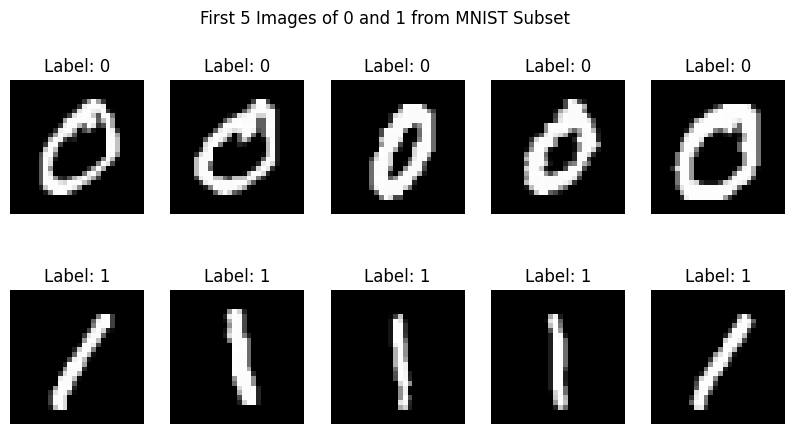

In [35]:
# create subplot
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        # show 0 image
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        # set title
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")  # hide axis

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")  # show 1 image
        axes[1, i].set_title("Label: 1")  # set title
        axes[1, i].axis("off")  # hide axis

# main title
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
# display plot
plt.show()

Initialize weights and bias

In [36]:
# initialize 784 weights and bias with zero
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1  # set learning rate
epochs = 100  # set total epochs

Question 3: What does the weights array represent in this context?

The weights array represents the importance of each input feature (pixel) in making a prediction. In the MNIST dataset, each image has 784 pixels, so there are 784 weights, one for each pixel. These weights determine how much influence each pixel has on the final output of the perceptron. During training, these weights are adjusted so that the model can correctly classify the input data.

Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Weights are initialized to zero as a simple starting point before training begins. It ensures that the model starts without any bias toward any particular feature. However, initializing all weights to zero can sometimes slow down learning because all features are treated equally at the beginning. In the perceptron, this is generally acceptable, but in more complex models, it may cause issues like slow convergence or lack of proper learning if not handled carefully.

Decision function

In [37]:
def decision_function(X, weights, bias):
    # compute weighted sum
    predictions = np.dot(X, weights) + bias
    # apply step function
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

Train perceptron

In [38]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    # repeat for many epochs
    for epoch in range(epochs):
        correct = 0  # count correct predictions

        # go through each sample
        for i in range(len(X)):
            # compute weighted sum
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0  # apply step function

            if y_pred == y[i]:
                correct += 1  # increase correct count
            else:
                error = y[i] - y_pred  # compute error
                weights = weights + learning_rate * error * X[i]  # update weights
                bias = bias + learning_rate * error  # update bias

        accuracy = correct / len(X)  # calculate epoch accuracy

    return weights, bias, accuracy

Question 5: What is the purpose of output = np.dot(X[i], weights) + bias?

The purpose of this line is to compute the weighted sum of the input features for a given sample. It multiplies each input value (pixel) by its corresponding weight and then adds the bias term. This result, called the net input, is used to determine the prediction of the perceptron after applying the activation function. Essentially, it represents the decision boundary calculation that helps classify the input as either 0 or 1.

Question 6: What happens when the prediction is wrong? How are the weights and bias updated?

When the prediction is incorrect, the perceptron updates its weights and bias to reduce the error and improve future predictions. The update is based on the difference between the true label and the predicted label (error). Each weight is adjusted using the formula: weight = weight + learning_rate * error * input, and the bias is updated as: bias = bias + learning_rate * error. This process helps shift the decision boundary so that the model becomes better at classifying the data correctly.

Question 7: Why is the final accuracy important, and what do you expect it to be?

Final accuracy is important because it measures how well the model has learned to classify the data correctly. It represents the proportion of correctly predicted samples out of the total samples. A high accuracy indicates that the perceptron has successfully learned the pattern in the data. For a simple task like classifying digits 0 and 1, we expect the accuracy to be very high, often close to 100%, since the data is usually linearly separable.

Train model

In [39]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)  # train model
print("The Final Accuracy is:", accuracy)  # print final accuracy

The Final Accuracy is: 1.0


Visualize misclassified images

In [40]:
predictions = np.dot(X, weights) + bias  # compute raw outputs
y_pred = np.where(predictions >= 0, 1, 0)  # convert to class labels

In [41]:
final_accuracy = np.mean(y_pred == y)  # calculate final accuracy
print(f"Final Accuracy: {final_accuracy:.4f}")  # print accuracy

Final Accuracy: 1.0000


In [42]:
misclassified_idx = np.where(y_pred != y)[0]  # get wrong prediction indices

In [43]:
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # create subplot

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")  # show wrong image
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")  # show labels
        ax.axis("off")  # hide axis

    plt.suptitle("Misclassified Images")  # set title
    plt.show()  # display images
else:
    print("All images were correctly classified!")  # print if no errors

All images were correctly classified!


Question 8: What does misclassified_idx store, and how is it used in this code?

The variable misclassified_idx stores the indices of all the samples where the model’s predictions do not match the true labels. In other words, it identifies which data points were incorrectly classified by the perceptron. This is useful for analysis because the code uses these indices to retrieve and display the corresponding images. By visualizing these misclassified images, we can better understand where the model is making mistakes and gain insights into its limitations.

Question 9: How do you interpret the result if the output is “All images were correctly classified!”?

If the output shows “All images were correctly classified!”, it means that the perceptron model has successfully predicted the correct label for every sample in the dataset. This indicates perfect accuracy on that dataset, suggesting that the data is linearly separable and the model has learned the decision boundary effectively. However, it is also important to note that perfect accuracy on training data does not always guarantee good performance on unseen data.

**Task 3: Perceptron Algorithm for 3 vs 5 Classification**

Load 3 vs 5 dataset

In [44]:
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv")  # load dataset
X_35 = df_3_5.drop(columns=["label"]).values  # take pixel values
y_35 = df_3_5["label"].values  # take labels

Convert labels to 0 and 1

In [45]:
y_35 = np.where(y_35 == 3, 0, 1)  # convert 3->0 and 5->1

In [46]:
weights_35 = np.zeros(X_35.shape[1])  # initialize weights
bias_35 = 0  # initialize bias

In [47]:
weights_35, bias_35, accuracy_35 = train_perceptron(X_35, y_35, weights_35, bias_35, learning_rate, epochs)  # train model
print("Final Accuracy for 3 vs 5:", accuracy_35)  # print accuracy

Final Accuracy for 3 vs 5: 0.9857716161984678


In [48]:
predictions_35 = np.dot(X_35, weights_35) + bias_35  # compute outputs
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)  # convert to labels

In [49]:
misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]  # find wrong predictions

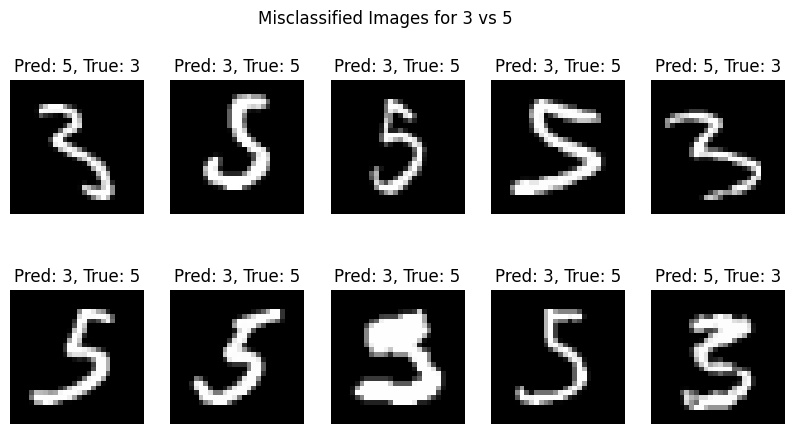

In [50]:
if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # create subplot

    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        pred_label = 3 if y_pred_35[idx] == 0 else 5  # convert predicted label back
        true_label = 3 if y_35[idx] == 0 else 5  # convert true label back

        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")  # show image
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")  # show labels
        ax.axis("off")  # hide axis

    plt.suptitle("Misclassified Images for 3 vs 5")  # set title
    plt.show()  # display images
else:
    print("All images were correctly classified!")  # print if no errors

Conclusion

In this task, the perceptron was used to classify digits 3 and 5. The model was able to learn and achieve a good level of accuracy by updating weights and bias during training. However, compared to 0 and 1, the accuracy is usually lower because 3 and 5 have similar shapes. The misclassified images show that the perceptron struggles with such similar patterns. This is because it is a linear model and cannot handle complex boundaries well. Overall, the perceptron works, but it has limitations for more difficult classification problems.